### Imports

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt


# (ALL) BEHAVIORAL ANALYSIS

In [ ]:
df = pd.read_parquet("C:\\Users\\dacdatalabs.ojt2\\Desktop\\workspace\\DS\\datasets\\combined_shoppers.parquet")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8320948 entries, 0 to 8320947
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   gcr_persistent_id      str    
 1   header_tran_date       str    
 2   department_cleaned     str    
 3   subdepartment_cleaned  str    
 4   subclass               str    
 5   total_sales            float64
 6   total_units            int64  
dtypes: float64(1), int64(1), str(5)
memory usage: 1.3 GB


In [4]:
customer_counts = df.groupby('gcr_persistent_id').size()
ids_to_keep = customer_counts[customer_counts <= 20].index
df = df[df['gcr_persistent_id'].isin(ids_to_keep)]
df.shape

(5646231, 7)

In [5]:
df.drop(df[df["subclass"] == "Md Promo"].index, inplace=True)
df.drop(df[df["subdepartment_cleaned"] == "Iw Promotions"].index, inplace=True)
df.drop(df[df["subdepartment_cleaned"] == "Iaf Clearance"].index, inplace=True)
df.drop(df[df["subdepartment_cleaned"] == "Iaf Promotions"].index, inplace=True)

In [6]:
df.shape

(5147251, 7)

In [7]:
df['header_tran_date'].isna().sum()

np.int64(0)

In [8]:
df['header_tran_date'] = pd.to_datetime(df['header_tran_date'], format='%d %b %Y', errors='coerce')
df['gcr_persistent_id'] = pd.factorize(df['gcr_persistent_id'])[0].astype(int)

In [9]:
df['header_tran_date'].isna().sum()

np.int64(326947)

In [10]:
df.head()

,gcr_persistent_id,header_tran_date,department_cleaned,subdepartment_cleaned,subclass,total_sales,total_units
2,0,2025-04-19,Babies Accs & Furn,Nursing & Feeding,Sc Nursing Supplies & Acc,159.00,1
5,1,2025-04-23,Babies' Wear,Newborn Essential 0-12 Mos,Tops,319.20,1
7,2,2025-04-01,Babies' Wear,Toddler Boys Casual,Bottoms,899.75,1
8,3,2025-04-03,Babies Accs & Furn,Personal Care,Sc Grooming Accessories,99.00,1
9,4,2025-04-01,Babies' Wear,Newborn Essential 0-12 Mos,Accessories,948.00,2


## Custom Table

### Feature Engineering

#### Recency 

In [ ]:
fe = df.copy()

fe = fe.sort_values(['gcr_persistent_id', 'header_tran_date'])
fe['purchase_order'] = fe.groupby('gcr_persistent_id').cumcount() + 1

In [12]:
fe['days_since_last_purchase'] = (
    fe.groupby('gcr_persistent_id')['header_tran_date']
      .diff()
      .dt.days
)

In [13]:

snapshot_date = fe['header_tran_date'].max()

recency = (
    fe.groupby('gcr_persistent_id')['header_tran_date']
      .max()
      .reset_index()
)

recent = recency['days_since_last_seen'] = (
    snapshot_date - recency['header_tran_date']
).dt.days

#### Cusotomer Timeline

In [14]:
fe['first_purchase_date'] = fe.groupby('gcr_persistent_id')['header_tran_date'].transform('min')

fe['customer_tenure_days'] = (
    fe['header_tran_date'] - fe['first_purchase_date']
).dt.days

In [15]:
fe['last_purchase_date'] = fe.groupby('gcr_persistent_id')['header_tran_date'].transform('max')

fe['lifecycle_length'] = (
    fe['last_purchase_date'] - fe['first_purchase_date']
).dt.days

fe['lifecycle_progress'] = fe['customer_tenure_days'] / fe['lifecycle_length']

#### Purchase rhythm

In [16]:
purchase_gap = fe.groupby('gcr_persistent_id')['days_since_last_purchase'].mean()
purchase_gap = purchase_gap.rename('avg_days_between_txn')

In [17]:
gap_std = fe.groupby('gcr_persistent_id')['days_since_last_purchase'].std()
gap_std = gap_std.rename('std_days_between_txn')

In [18]:
cv = gap_std / purchase_gap
cv = cv.rename('purchase_regularity')

In [19]:
fe.head()

,gcr_persistent_id,header_tran_date,department_cleaned,subdepartment_cleaned,subclass,total_sales,total_units,purchase_order,days_since_last_purchase,first_purchase_date,customer_tenure_days,last_purchase_date,lifecycle_length,lifecycle_progress
2,0,2025-04-19,Babies Accs & Furn,Nursing & Feeding,Sc Nursing Supplies & Acc,159.0,1,1,NaN,2025-04-19,0.0,2025-04-19,0.0,NaN
5,1,2025-04-23,Babies' Wear,Newborn Essential 0-12 Mos,Tops,319.2,1,1,NaN,2025-04-23,0.0,2025-12-08,229.0,0.000000
32450,1,2025-04-23,Babies' Wear,Newborn Essential 0-12 Mos,Bottoms,214.5,1,2,0.0,2025-04-23,0.0,2025-12-08,229.0,0.000000
5914635,1,2025-05-11,Babies' Wear,Newborn Essential 0-12 Mos,Tops,399.0,1,3,18.0,2025-04-23,18.0,2025-12-08,229.0,0.078603
5919112,1,2025-05-11,Babies' Wear,Newborn Essential 0-12 Mos,Tops,349.0,1,4,0.0,2025-04-23,18.0,2025-12-08,229.0,0.078603


| Pattern                | Meaning                                     |
| ---------------------- | ------------------------------------------- |
| Low avg gap + low std  | Routine buyer (predictable parent behavior) |
| Low avg gap + high std | Burst buying (stockpiling)                  |
| High avg gap           | Low engagement / late-stage                 |


#### Burst vs Routine Detection 

In [20]:
fe['is_quick_repeat'] = fe['days_since_last_purchase'] <= 7

In [21]:
burst_ratio = (
    fe.groupby('gcr_persistent_id')['is_quick_repeat']
      .mean()
      .rename('burst_ratio')
)

#### Time Between First Few Purchases

In [22]:
fe['purchase_order'] = fe.groupby('gcr_persistent_id').cumcount() + 1

first3 = fe.loc[fe['purchase_order'] <= 3, ['gcr_persistent_id', 'header_tran_date']]

agg = first3.groupby('gcr_persistent_id')['header_tran_date'].agg(['min', 'max'])
early_speed = (agg['max'] - agg['min']).dt.days.rename('first_3_txn_span')


#### Monthly / Weekly Behavior

In [23]:
fe['year_month'] = fe['header_tran_date'].dt.to_period('M')

monthly_txn = (
    fe.groupby(['gcr_persistent_id', 'year_month'])
      .size()
      .reset_index(name='txn_count')
)

In [24]:
active_months = (
    monthly_txn.groupby('gcr_persistent_id')['year_month']
               .nunique()
               .rename('active_months')
)

#### Time Feature Set 

| Feature Name             | Definition                            | How It’s Computed                  | Behavioral Meaning          | How to Use It                 |
| ------------------------ | ------------------------------------- | ---------------------------------- | --------------------------- | ----------------------------- |
| **customer_id**          | Unique shopper ID                     | `gcr_persistent_id`                | Identifies each shopper     | Primary key                   |
| **total_txns**           | Total number of purchases             | Count of transactions              | Overall engagement level    | Segment heavy vs light buyers |
| **avg_days_between_txn** | Average gap between purchases         | Mean of `days_since_last_purchase` | Purchase frequency          | Low = frequent buyer          |
| **std_days_between_txn** | Variability of purchase timing        | Std of gaps                        | Consistency of behavior     | High = irregular              |
| **purchase_regularity**  | Consistency score                     | std / avg                          | Stability of shopping habit | Low = routine, High = erratic |
| **burst_ratio**          | % of quick repeat purchases (≤7 days) | Mean of `is_quick_repeat`          | Intensity / urgency         | High = newborn or stockpiling |
| **first_3_txn_span**     | Days between first 3 purchases        | max - min of first 3 txn dates     | Early-stage urgency         | Short = urgent need           |
| **lifecycle_length**     | Total active duration                 | last - first purchase              | Length of engagement        | Long = sustained customer     |
| **active_months**        | Number of months with activity        | Unique months with transactions    | Engagement spread           | High = consistent shopper     |
| **days_since_last_seen** | Recency (churn signal)                | Snapshot - last purchase           | How recently they shopped   | High = churn risk             |


In [25]:
total_txns = fe.groupby('gcr_persistent_id').size().rename('total_txns')

time_features = pd.concat([
    purchase_gap,
    gap_std,
    cv,
    burst_ratio,
    recent,
    early_speed,
    active_months,
    total_txns
], axis=1).reset_index()

In [26]:
time_features.head(20)

,index,avg_days_between_txn,std_days_between_txn,purchase_regularity,burst_ratio,header_tran_date,first_3_txn_span,active_months,total_txns
0,0,NaN,NaN,NaN,0.000000,256.0,0.0,1.0,1
1,1,32.714286,78.902290,2.411860,0.625000,23.0,18.0,3.0,8
2,2,16.500000,31.646485,1.917969,0.571429,254.0,79.0,2.0,7
3,3,0.000000,0.000000,NaN,0.833333,272.0,0.0,1.0,6
4,4,0.000000,0.000000,NaN,0.909091,274.0,0.0,1.0,11
5,5,182.000000,NaN,NaN,0.000000,82.0,182.0,2.0,2
6,6,12.785714,18.493985,1.446457,0.600000,123.0,0.0,6.0,15
7,7,1.000000,3.464102,3.464102,0.647059,238.0,0.0,2.0,17
8,8,NaN,NaN,NaN,0.000000,247.0,0.0,1.0,1
9,9,0.000000,NaN,NaN,0.500000,255.0,0.0,1.0,2


In [28]:
# plt.hist2d(
#     time_features['total_txns'],
#     time_features['avg_days_between_txn'],
#     bins=[50, 50]
# )
# plt.colorbar(label='Number of Customers')
# plt.xlabel('Total Transactions')
# plt.ylabel('Avg Days Between Transactions')
# plt.title('Customer Density by Total Transactions and Avg Days Between Transactions')
# plt.show()

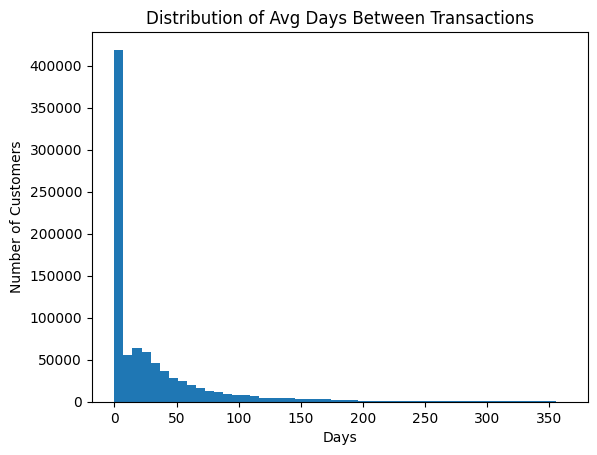

In [29]:
import matplotlib.pyplot as plt

plt.hist(time_features['avg_days_between_txn'].dropna(), bins=50)
plt.title('Distribution of Avg Days Between Transactions')
plt.xlabel('Days')
plt.ylabel('Number of Customers')
plt.show()

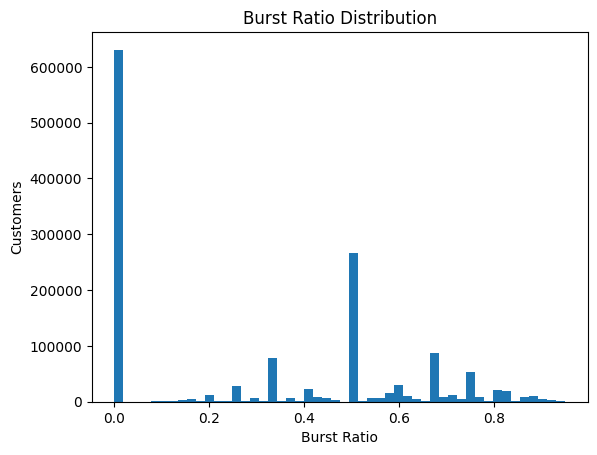

In [30]:
plt.hist(time_features['burst_ratio'].dropna(), bins=50)
plt.title('Burst Ratio Distribution')
plt.xlabel('Burst Ratio')
plt.ylabel('Customers')
plt.show()

In [32]:
plt.hist(time_features['days_since_last_seen'], bins=50)
plt.title('Recency Distribution')
plt.xlabel('Days Since Last Seen')
plt.ylabel('Customers')
plt.show()

KeyError: 'days_since_last_seen'

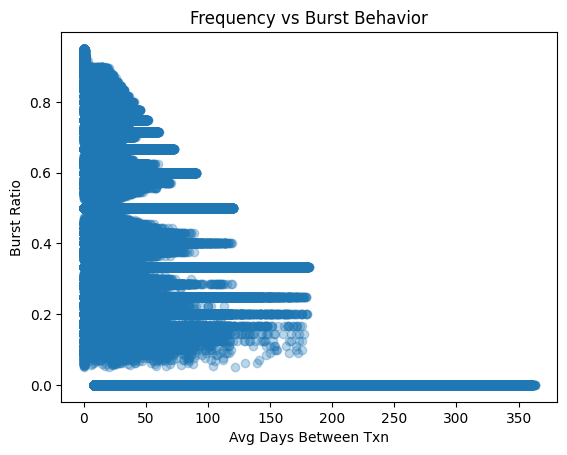

In [33]:
plt.scatter(
    time_features['avg_days_between_txn'],
    time_features['burst_ratio'],
    alpha=0.3
)

plt.xlabel('Avg Days Between Txn')
plt.ylabel('Burst Ratio')
plt.title('Frequency vs Burst Behavior')
plt.show()

In [34]:
plt.scatter(
    time_features['avg_days_between_txn'],
    time_features['days_since_last_seen'],
    alpha=0.3
)

plt.xlabel('Avg Days Between Txn')
plt.ylabel('Days Since Last Seen')
plt.title('Churn vs Frequency')
plt.show()

KeyError: 'days_since_last_seen'

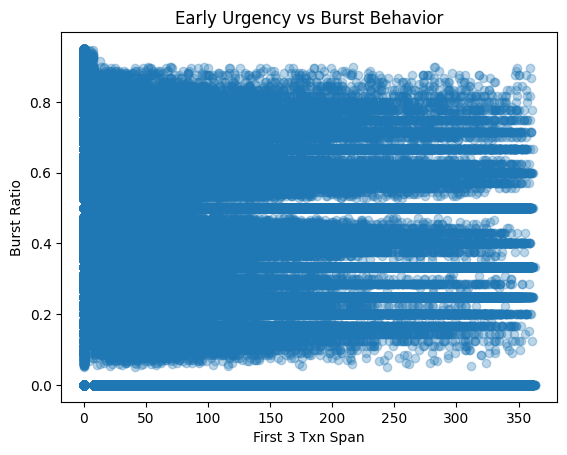

In [35]:
plt.scatter(
    time_features['first_3_txn_span'],
    time_features['burst_ratio'],
    alpha=0.3
)

plt.xlabel('First 3 Txn Span')
plt.ylabel('Burst Ratio')
plt.title('Early Urgency vs Burst Behavior')
plt.show()

## Transition Analysis

In [36]:
df['next_category'] = df.groupby('gcr_persistent_id')['subdepartment_cleaned'].shift(-1)

transitions = (
    df.groupby(['subdepartment_cleaned', 'next_category'])
    .size()
    .reset_index(name='count')
)

transitions['prob'] = transitions.groupby('subdepartment_cleaned')['count'].transform(lambda x: x / x.sum())

In [37]:
transitions[
    transitions['subdepartment_cleaned'] != transitions['next_category']
].sort_values('count', ascending=False).head(10)

,subdepartment_cleaned,next_category,count,prob
545,Toiletries,Nursing & Feeding,106997,0.158839
314,Nursing & Feeding,Toiletries,106857,0.198444
279,Newborn Essential 0-12 Mos,Nursing & Feeding,57879,0.083612
303,Nursing & Feeding,Newborn Essential 0-12 Mos,57844,0.107422
289,Newborn Essential 0-12 Mos,Toiletries,56843,0.082116
544,Toiletries,Newborn Essential 0-12 Mos,56124,0.083317
269,Newborn Essential 0-12 Mos,Baby Girl Fashion 0-24 Mos,49478,0.071476
59,Baby Girl Fashion 0-24 Mos,Newborn Essential 0-12 Mos,48899,0.235652
166,Disposable Diapers,Toiletries,39542,0.336571
538,Toiletries,Disposable Diapers,39386,0.058469


## JOURNEY

In [38]:
mapping = {
    'Newborn Essential 0-12mos': 'Early Care',
    'Nursing & Feeding': 'Early Care',
    'Toiletries': 'Daily Care',
    'Food and Supplements': 'Growth',
    'Clothing': 'Lifestyle',
    'Carriers & Wheeled Goods': 'Mobility'
}

df['journey_stage'] = df['subdepartment_cleaned'].map(mapping)

In [39]:
df.groupby(['journey_stage', 'subdepartment_cleaned']).size().reset_index(name='count')

,journey_stage,subdepartment_cleaned,count
0,Daily Care,Toiletries,861826
1,Early Care,Nursing & Feeding,697397
2,Mobility,Carriers & Wheeled Goods,66766


# MODEL

### EDA

In [40]:
clean["department_cleaned"].unique()

# Clean text fields
clean['class'] = clean['class'].str.lower().str.strip()
clean['subclass'] = clean['subclass'].str.lower().str.strip()
clean['subdepartment_cleaned'] = clean['subdepartment_cleaned'].str.lower().str.strip()
clean['department_cleaned'] = clean['department_cleaned'].str.lower().str.strip()

NameError: name 'clean' is not defined

In [ ]:
clean.head()

### Feature Engineering

In [ ]:
clean = clean.copy()

In [ ]:
#time stamp col
clean['timestamp'] = pd.to_datetime(
    clean['header_tran_date'] + ' ' + clean['header_tran_time']
)

clean = clean.sort_values(['gcr_persistent_id', 'timestamp'])
clean

In [ ]:
#health
health_keywords = [
    'Allergy', 'Cough', 'Flu', 'Pain', 'Vitamin', 'Calcium'
]

clean['is_health'] = clean['subclass'].str.contains('|'.join(health_keywords), case=False, na=False)

In [ ]:
#suplement
supplement_keywords = ['vit', 'calcium', 'multivitamins, adult multi vitamins']

clean['is_supplement'] =clean['subclass'].str.contains('|'.join(supplement_keywords), case=False, na=False)

In [ ]:
#sensitive skincare
sensitive_keywords = [
    'facial', 'derma', 'acne', 'serum', 'moistur', 'sun', 'anti aging'
]

clean['is_sensitive'] = clean['subclass'].str.contains('|'.join(sensitive_keywords), case=False, na=False)

In [ ]:
#hygiene
hygiene_keywords = [
    'sanitary', 'panty', 'femwash', 'tooth', 'mouthwash', 'soap', 'bodywash'
]

clean['is_hygiene'] = clean['subclass'].str.contains('|'.join(hygiene_keywords), case=False, na=False)

In [ ]:
#beauty
beauty_keywords = [
    'cosmetic', 'lip', 'eye', 'fragrance', 'hair', 'nail'
]

clean['is_beauty'] = clean['subclass'].str.contains('|'.join(beauty_keywords), case=False, na=False)

In [ ]:
#baby 
baby_keywords = ['baby']

clean['is_baby_subclass'] = clean['subclass'].str.contains('|'.join(baby_keywords), na=False)

clean['is_baby_subdept'] = clean['subdepartment_cleaned'].eq('baby c + o')

# --- final baby flag ---
clean['is_baby'] = (
    clean['is_baby_subclass'] |
    clean['is_baby_subdept']
).astype(int)

In [ ]:
#health - beauty
clean['health_minus_beauty'] = clean['is_health'].astype(int) - clean['is_beauty'].astype(int)

In [ ]:
basket = (
    clean.groupby(['gcr_persistent_id', 'header_tran_key'])
      .agg({
          'department_cleaned': 'nunique',
          'pos_sku_tot_qty': 'sum',
          'pos_sku_gross_sales': 'sum'
      })
      .rename(columns={
          'department_cleaned': 'num_categories',
          'pos_sku_tot_qty': 'basket_qty',
          'pos_sku_gross_sales': 'basket_spend'
      })
      .reset_index()
)

basket['multi_category'] = (basket['num_categories'] > 1).astype(int)
basket['bulk_purchase'] = (basket['basket_qty'] > 3).astype(int)
basket

In [ ]:
clean = clean.set_index('timestamp')

rolling = (
    clean.groupby('gcr_persistent_id')
      .rolling('30D')
      .agg({
          'pos_sku_gross_sales': 'sum',
          'pos_sku_tot_qty': 'sum',
          'is_health': 'sum',
          'is_supplement': 'sum',
          'is_sensitive': 'sum',
          'is_hygiene': 'sum',
          'is_beauty': 'sum'
      })
      .reset_index()
)
rolling

In [ ]:
rolling = rolling.rename(columns={
    'pos_sku_gross_sales': 'total_spend_30d',
    'pos_sku_tot_qty': 'total_qty_30d',
    'is_health': 'health_count_30d',
    'is_supplement': 'supplement_count_30d',
    'is_sensitive': 'sensitive_count_30d',
    'is_hygiene': 'hygiene_count_30d',
    'is_beauty': 'beauty_count_30d'
})

In [ ]:
rolling['total_behavior'] = rolling[
    ['health_count_30d','beauty_count_30d','hygiene_count_30d']
].sum(axis=1)

rolling['health_ratio'] = rolling['health_count_30d'] / (rolling['total_behavior'] + 1)
rolling['sensitive_ratio'] = rolling['sensitive_count_30d'] / (rolling['total_qty_30d'] + 1)
rolling['supplement_ratio'] = rolling['supplement_count_30d'] / (rolling['total_behavior'] + 1)

In [ ]:
clean_reset = clean.reset_index()

clean_reset['prev_cat'] = clean_reset.groupby('gcr_persistent_id')['department_cleaned'].shift()

clean_reset['category_switch'] = (
    clean_reset['department_cleaned'] != clean_reset['prev_cat']
).astype(int)

switch = (
    clean_reset.groupby('gcr_persistent_id')['category_switch']
    .rolling(30, min_periods=1)
    .sum()
    .reset_index()
    .rename(columns={'category_switch': 'category_switch_count'})
)

In [ ]:
clean_reset = clean.reset_index()

# Ensure timestamp column exists
if 'timestamp' not in clean_reset.columns:
    clean_reset['timestamp'] = pd.to_datetime(
        clean_reset['header_tran_date'] + ' ' + clean_reset['header_tran_time']
    )

In [ ]:
last_purchase = (
    clean_reset.groupby('gcr_persistent_id')['timestamp']
    .max()
    .reset_index()
)

rolling = rolling.merge(last_purchase, on='gcr_persistent_id', how='left')

rolling['days_since_last_purchase'] = (
    rolling['timestamp'] - rolling['timestamp_y']
).dt.days

In [ ]:
future = (
    clean_reset.groupby('gcr_persistent_id')
    .rolling('60D', on='timestamp')['is_baby']
    .max()
    .reset_index()
    .rename(columns={'is_baby': 'label'})
    
)

future

In [ ]:
final_df = rolling.merge(
    future,
    on=['gcr_persistent_id', 'timestamp'],
    how='left'
)

final_df['label'] = final_df['label'].fillna(0)

In [ ]:
final_df.head(20)

In [ ]:
test = final_df.drop_duplicates(subset=["timestamp"])
test